# GlobalCLIP -- 01: Inspect and prepare datasets

Loads the four `.pt.gz` data files, verifies their structure, shows signal
statistics, and confirms that the GlobalCLIP and eCLIP datasets share
the same genomic regions (required for the CombiLayer approach).

**Outputs written by this notebook:**
- `results/globalclip/datasets/rbp_names.txt`   — ordered list of the 223 RBP names
- `results/globalclip/datasets/data_stats.json` — split sizes and signal statistics


## Set-up

### Imports

In [1]:
import pylbsr.notebooks
import pylbsr.misc

import gzip
import io
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap


### Initialisation

In [2]:
_notebook_name = "01_prepare_dataset.py.ipynb"
_notebook_path = f"notebooks/globalclip/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")


[09:04:06] INFO - Project directory: /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head


### Parameters

In [3]:
# Which control to use as primary training dataset.
# Options: "globalclip_lysate_noNHS" (recommended), "globalclip_interphase", "globalclip_lysate"
params_primary_control = "globalclip_lysate_noNHS"

# How many samples to print signal statistics for
params_n_inspect = 5


⏱ 0.00 s (00:00:00)


### Filepaths

In [4]:
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.server.yaml").read_text())

def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p

FILEPATHS = DotMap()
FILEPATHS.eclip             = _res(_fp_cfg["data"]["eclip"]["pt"])
FILEPATHS.eclip_rbp_tsv     = _res(_fp_cfg["data"]["eclip"]["rbp_tsv"])
FILEPATHS.primary_globalclip = _res(_fp_cfg["data"][params_primary_control]["pt"])
FILEPATHS.interphase        = _res(_fp_cfg["data"]["globalclip_interphase"]["pt"])
FILEPATHS.lysate            = _res(_fp_cfg["data"]["globalclip_lysate"]["pt"])
FILEPATHS.lysate_noNHS      = _res(_fp_cfg["data"]["globalclip_lysate_noNHS"]["pt"])
FILEPATHS.out_dir           = PROJECT_DIR / "results" / "globalclip" / "datasets"
FILEPATHS.out_dir.mkdir(parents=True, exist_ok=True)

for k, v in FILEPATHS.items():
    logger.info(f"{k:25s}: {v}")


[09:04:06] INFO - eclip                    : /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/eCLIP_600bp_signalfiltered.pt.gz
[09:04:06] INFO - eclip_rbp_tsv            : /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/eCLIP_600bp_signalfiltered.rbp_cts.tsv
[09:04:06] INFO - primary_globalclip       : /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/globalclip_lysate_noNHS_600bp_signalfiltered.pt.gz
[09:04:06] INFO - interphase               : /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/globalclip_interphase_600bp_signalfiltered.pt.gz
[09:04:06] INFO - lysate                   : /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/globalclip_lysate_600bp_signalfiltered.pt.gz
[09:04:06] INFO - lysate_noNHS             : /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_

⏱ 0.02 s (00:00:00)


## Load eCLIP data and extract RBP metadata

The eCLIP file contains 223 RBP tracks. We load the TSV sidecar to get
the ordered list of RBP names that corresponds to track indices 0–222.

In [5]:
rbp_df = pd.read_csv(FILEPATHS.eclip_rbp_tsv, sep="\t")
rbp_names = rbp_df["rbp_ct"].tolist()
logger.info(f"Loaded {len(rbp_names)} RBP names from TSV.")
logger.info(f"First 5: {rbp_names[:5]}")
logger.info(f"Last  5: {rbp_names[-5:]}")

# Save for use in later notebooks
(FILEPATHS.out_dir / "rbp_names.txt").write_text("\n".join(rbp_names))
rbp_df.to_csv(FILEPATHS.out_dir / "rbp_cts.tsv", sep="\t", index=False)
logger.info(f"Saved RBP names to {FILEPATHS.out_dir / 'rbp_names.txt'}")


[09:04:06] INFO - Loaded 223 RBP names from TSV.
[09:04:06] INFO - First 5: ['AARS_K562', 'AATF_K562', 'ABCF1_K562', 'AGGF1_HepG2', 'AGGF1_K562']
[09:04:06] INFO - Last  5: ['ZC3H8_K562', 'ZNF622_K562', 'ZNF800_HepG2', 'ZNF800_K562', 'ZRANB2_K562']
[09:04:06] INFO - Saved RBP names to /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/datasets/rbp_names.txt


⏱ 0.08 s (00:00:00)


In [6]:
# Cell line distribution
cell_lines = rbp_df["rbp_ct"].str.extract(r"_(HepG2|K562)$")[0].value_counts()
print(f"Cell line distribution in the 223 tracks:\n{cell_lines}")
print(f"\nSample RBPs per cell line:")
for cl in ["HepG2", "K562"]:
    examples = [n for n in rbp_names if n.endswith(f"_{cl}")][:5]
    print(f"  {cl}: {examples}")


Cell line distribution in the 223 tracks:
0
K562     120
HepG2    103
Name: count, dtype: int64

Sample RBPs per cell line:
  HepG2: ['AGGF1_HepG2', 'AKAP1_HepG2', 'AQR_HepG2', 'BCCIP_HepG2', 'BCLAF1_HepG2']
  K562: ['AARS_K562', 'AATF_K562', 'ABCF1_K562', 'AGGF1_K562', 'AKAP1_K562']
⏱ 0.00 s (00:00:00)


## Inspect a GlobalCLIP dataset

Load one element from the primary GlobalCLIP dataset and verify its structure.

In [7]:
from parnet_demo_utils.sparse_utils import torch_sparse_to_dense

logger.info(f"Loading primary GlobalCLIP dataset: {FILEPATHS.primary_globalclip.name}")
with gzip.open(FILEPATHS.primary_globalclip, "rb") as f:
    gc_data = torch.load(io.BytesIO(f.read()), weights_only=False)

print("Top-level keys:", list(gc_data.keys()))
for split, samples in gc_data.items():
    print(f"  {split}: {len(samples)} samples")


[09:04:10] INFO - Loading primary GlobalCLIP dataset: globalclip_lysate_noNHS_600bp_signalfiltered.pt.gz


Top-level keys: ['valid', 'train', 'test', 'metadata']
  valid: 7361 samples
  train: 39052 samples
  test: 4946 samples
  metadata: 6 samples
⏱ 14.03 s (00:00:14)


In [8]:
# Inspect one element
elem = gc_data["train"][0]
print("Element keys         :", list(elem.keys()))
print("Input keys           :", list(elem["inputs"].keys()))
print("Output keys          :", list(elem["outputs"].keys()))
print("Sequence (first 30nt):", elem["inputs"]["sequence"][:30], "...")
print("Sequence length      :", len(elem["inputs"]["sequence"]))

signal  = torch_sparse_to_dense(elem["outputs"]["globalCLIP"])
control = torch_sparse_to_dense(elem["outputs"]["control"])
print(f"Signal shape         : {tuple(signal.shape)}  (should be (1, 600))")
print(f"Control shape        : {tuple(control.shape)} (should be (1, 600))")
print(f"Signal total reads   : {int(signal.sum())}")
print(f"Control total reads  : {int(control.sum())}")
print(f"Region name          : {elem.get('meta', {}).get('name', 'N/A')}")


Element keys         : ['meta', 'inputs', 'outputs']
Input keys           : ['sequence']
Output keys          : ['globalCLIP', 'control']
Sequence (first 30nt): TACTGAGCTGCTTTTGTGATTTGAGCATTT ...
Sequence length      : 600
Signal shape         : (1, 600)  (should be (1, 600))
Control shape        : (1, 600) (should be (1, 600))
Signal total reads   : 705
Control total reads  : 298
Region name          : chr4:3512611-3513211:-
⏱ 0.00 s (00:00:00)


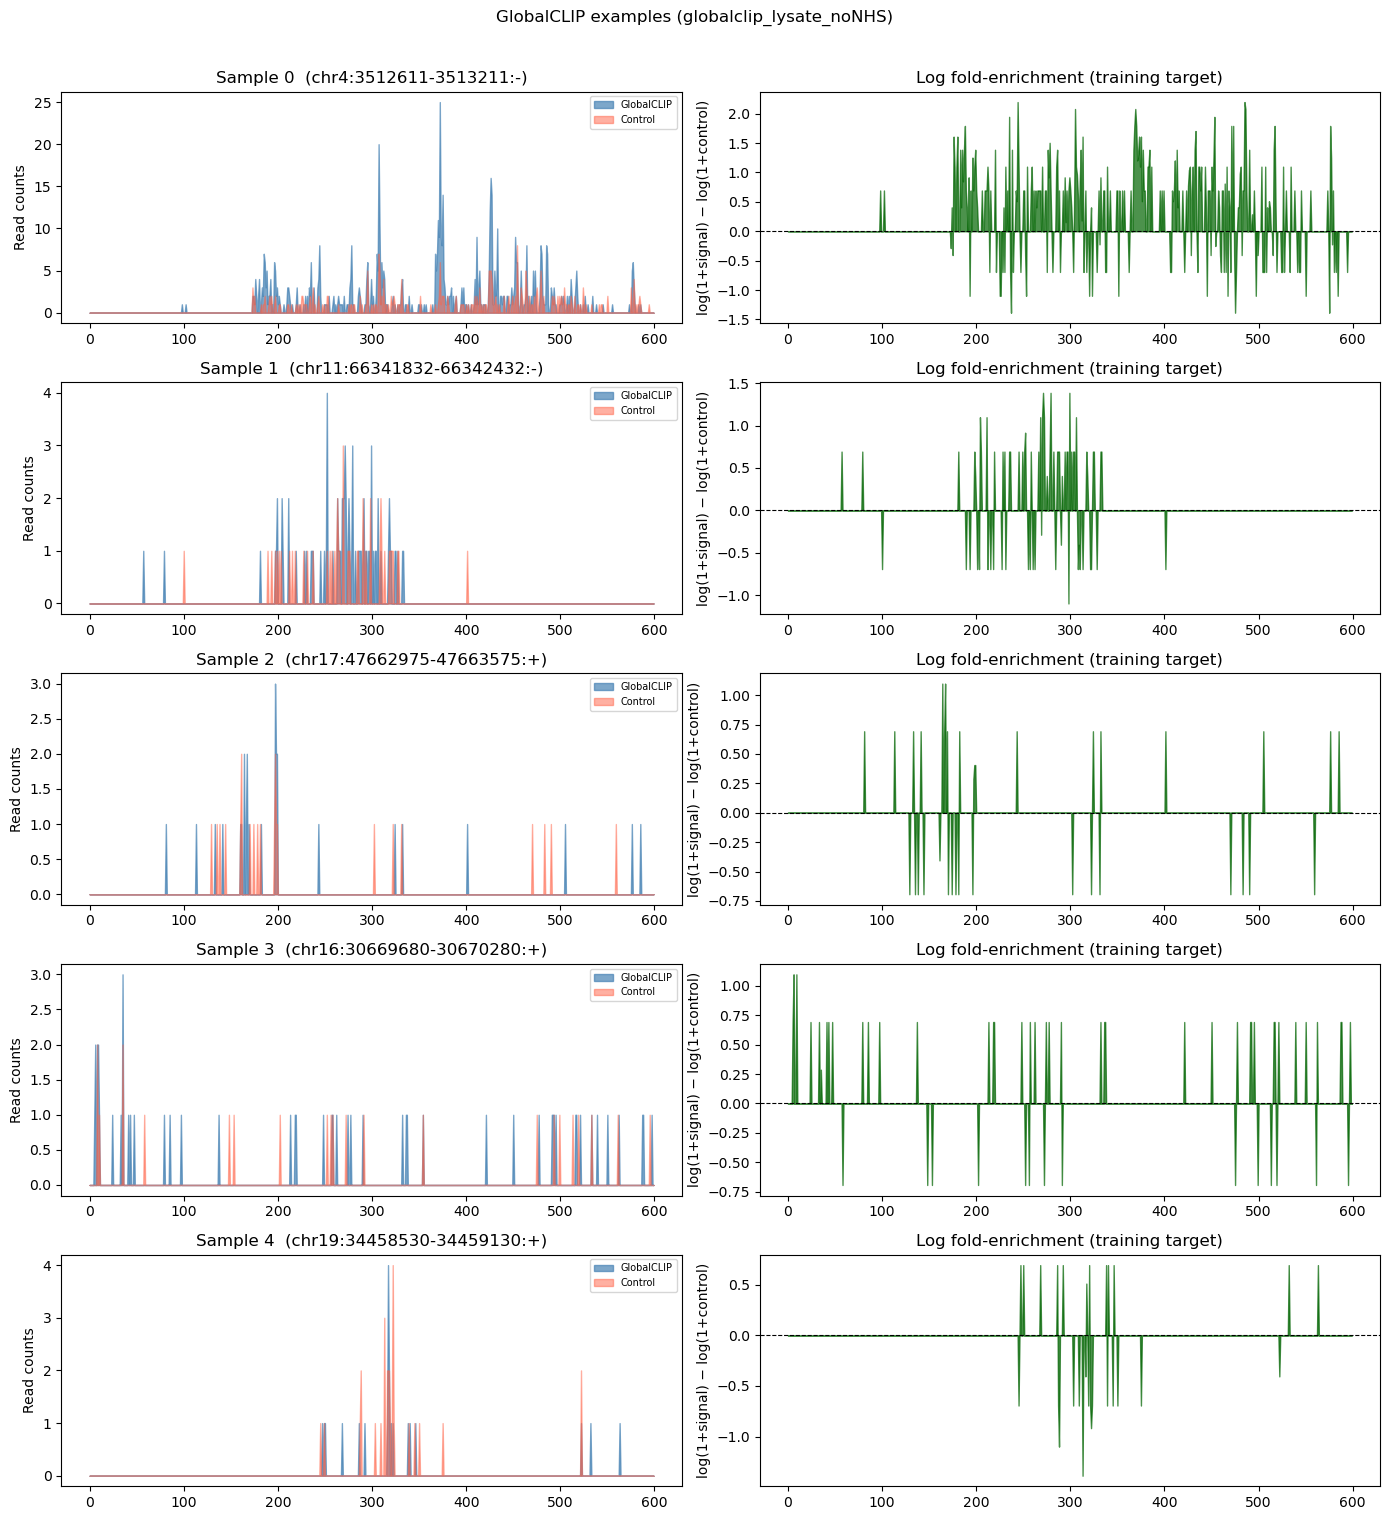

⏱ 2.07 s (00:00:02)


In [9]:
# Plot signal vs control for the first few samples
fig, axes = plt.subplots(params_n_inspect, 2, figsize=(14, 3 * params_n_inspect))
for i in range(params_n_inspect):
    e = gc_data["train"][i]
    sig = torch_sparse_to_dense(e["outputs"]["globalCLIP"]).squeeze(0).numpy()
    ctl = torch_sparse_to_dense(e["outputs"]["control"]).squeeze(0).numpy()
    log_fe = np.log1p(sig) - np.log1p(ctl)

    axes[i, 0].fill_between(range(600), sig, alpha=0.7, color="steelblue", label="GlobalCLIP")
    axes[i, 0].fill_between(range(600), ctl, alpha=0.5, color="tomato",    label="Control")
    axes[i, 0].set_ylabel("Read counts")
    axes[i, 0].legend(fontsize=7)
    axes[i, 0].set_title(f"Sample {i}  ({e.get('meta',{}).get('name','?')[:30]})")

    axes[i, 1].fill_between(range(600), log_fe, alpha=0.7, color="darkgreen")
    axes[i, 1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[i, 1].set_ylabel("log(1+signal) − log(1+control)")
    axes[i, 1].set_title("Log fold-enrichment (training target)")

plt.suptitle(f"GlobalCLIP examples ({params_primary_control})", y=1.01)
plt.tight_layout()
plt.savefig(FILEPATHS.out_dir / "sample_profiles.png", dpi=120, bbox_inches="tight")
plt.show()


## Compare the three control types

All three GlobalCLIP files share the same `globalCLIP` signal but differ
in the `control` track. Here we compare them on the same region to visualise
the noise characteristics of each control.

In [10]:
logger.info("Loading interphase and lysate datasets for comparison...")

with gzip.open(FILEPATHS.interphase, "rb") as f:
    iph_data = torch.load(io.BytesIO(f.read()), weights_only=False)
with gzip.open(FILEPATHS.lysate, "rb") as f:
    lys_data = torch.load(io.BytesIO(f.read()), weights_only=False)
with gzip.open(FILEPATHS.lysate_noNHS, "rb") as f:
    lys_noNHS_data = torch.load(io.BytesIO(f.read()), weights_only=False)

logger.info("All datasets loaded.")


[09:04:22] INFO - Loading interphase and lysate datasets for comparison...
[09:04:58] INFO - All datasets loaded.


⏱ 35.68 s (00:00:35)


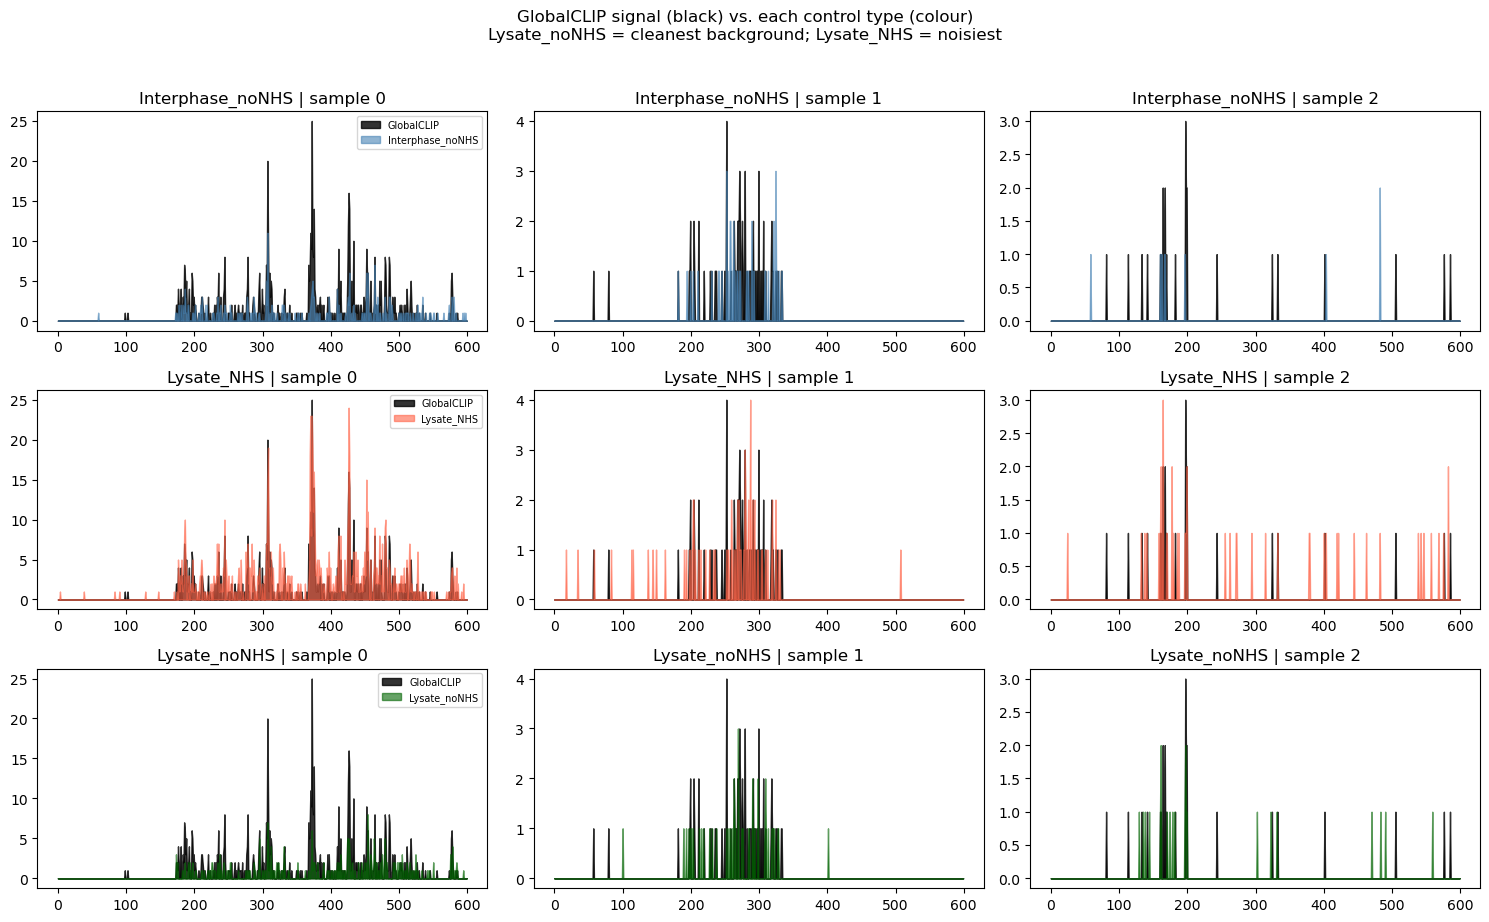

⏱ 1.80 s (00:00:01)


In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
n_show = 3
controls = [
    (iph_data,       "Interphase_noNHS",  "steelblue"),
    (lys_data,       "Lysate_NHS",        "tomato"),
    (lys_noNHS_data, "Lysate_noNHS",      "darkgreen"),
]
for row, (data, name, color) in enumerate(controls):
    for col in range(n_show):
        e   = data["train"][col]
        sig = torch_sparse_to_dense(e["outputs"]["globalCLIP"]).squeeze().numpy()
        ctl = torch_sparse_to_dense(e["outputs"]["control"]).squeeze().numpy()
        ax = axes[row, col]
        ax.fill_between(range(600), sig, alpha=0.8, color="black",   label="GlobalCLIP" if col==0 else "")
        ax.fill_between(range(600), ctl, alpha=0.6, color=color,      label=name         if col==0 else "")
        ax.set_title(f"{name} | sample {col}")
        if col == 0:
            ax.legend(fontsize=7)

plt.suptitle("GlobalCLIP signal (black) vs. each control type (colour)\n"
             "Lysate_noNHS = cleanest background; Lysate_NHS = noisiest",
             y=1.02)
plt.tight_layout()
plt.savefig(FILEPATHS.out_dir / "control_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## Signal statistics and data quality summary

In [14]:
def summarise_dataset(data, name):
    """Compute read count statistics across all splits."""
    rows = []
    known_splits = {"train", "valid", "val", "test"}
    for split, samples in data.items():
        if split not in known_splits:
            continue
        items = list(samples.values()) if isinstance(samples, dict) else list(samples)
        totals = [torch_sparse_to_dense(e["outputs"]["globalCLIP"]).sum().item()
                  for e in items]
        rows.append({
            "dataset":       name,
            "split":         split,
            "n_samples":     len(items),
            "signal_mean":   np.mean(totals),
            "signal_median": np.median(totals),
        })
    return rows

stats_rows = []
for data, name in [(iph_data, "interphase"), (lys_data, "lysate_NHS"),
                   (lys_noNHS_data, "lysate_noNHS")]:
    stats_rows.extend(summarise_dataset(data, name))

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))

stats_df.to_csv(FILEPATHS.out_dir / "data_stats.csv", index=False)
logger.info(f"Statistics saved to {FILEPATHS.out_dir / 'data_stats.csv'}")

[09:10:24] INFO - Statistics saved to /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/datasets/data_stats.csv


     dataset split  n_samples  signal_mean  signal_median
  interphase valid       7361   106.664719           41.0
  interphase train      39052   165.041509           44.0
  interphase  test       4946    92.591994           43.0
  lysate_NHS valid       7361   106.664719           41.0
  lysate_NHS train      39052   165.041509           44.0
  lysate_NHS  test       4946    92.591994           43.0
lysate_noNHS valid       7361   106.664719           41.0
lysate_noNHS train      39052   165.041509           44.0
lysate_noNHS  test       4946    92.591994           43.0
⏱ 2.03 s (00:00:02)


## Summary

All three GlobalCLIP datasets share the same `globalCLIP` signal (same 39052
train / 7361 valid / 4946 test regions). Only the control track differs:

| Control | Biological meaning | Noise level |
|---|---|---|
| `lysate_noNHS` | Free RNA in lysate (cleanest baseline) | lowest |
| `interphase` | Interphase pellet: protein-RNA complexes + free RNA | medium |
| `lysate_NHS` | NHS bead pull-down of free proteins | highest |

**Recommended for training:** `globalclip_lysate_noNHS` (lowest background),
or `globalclip_interphase` for a biologically-motivated control that still
shares the same enrichment protocol as the signal.

**Next steps:**
- `02a_train_standard.py.ipynb` — train the MixCoeffHead+log_scale model
- `02b_train_qlayer.py.ipynb`   — train the QLayer interference model
